In [52]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
import json
import matplotlib.pyplot as plt

from xcube.core.store import new_data_store
from xcube.core.chunk import chunk_dataset
from xcube.core.gridmapping import GridMapping
from xcube.core.geom import mask_dataset_by_geometry
from xcube_resampling.spatial import resample_in_space
from xcube_resampling.gridmapping import GridMapping

In [95]:
fsd = new_data_store("file", root="output")

In [2]:
cci_ds = new_data_store("cciodp")

In [15]:
bbox = [-5, 40, 3, 44]
time_range = ["2015-01-01", "2015-12-31"]

In [16]:
lc_cci = cci_ds.open_data(
    "esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform.Map.2-0-7.r1", 
    bbox=bbox, 
    time_range=time_range,
)

In [17]:
lc_cci

<xarray.Dataset> Size: 83MB
Dimensions:              (time: 1, lat: 1440, lon: 2880, bnds: 2)
Coordinates:
  * lat                  (lat) float32 6kB 44.0 44.0 43.99 ... 40.01 40.0 40.0
  * lon                  (lon) float32 12kB -4.999 -4.996 -4.993 ... 2.996 2.999
  * time                 (time) datetime64[ns] 8B 2015-07-02T12:00:00
    time_bnds            (time, bnds) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    change_count         (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 2880), meta=np.ndarray>
    crs                  float64 8B ...
    current_pixel_state  (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 2880), meta=np.ndarray>
    lccs_class           (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 2880), meta=np.ndarray>
    observation_count    (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 2880), meta=np.ndarray>
    processed_flag       (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 2880), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform...
    date_created:            2025-08-26T16:03:30.413416
    processing_level:        L4
    time_coverage_start:     2015-01-01T00:00:00
    time_coverage_end:       2016-01-01T00:00:00
    time_coverage_duration:  P365DT0H0M0S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

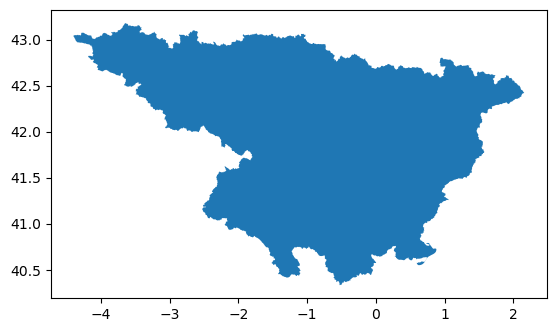

In [18]:
gdf = gpd.read_file("ebro_data/Limite_Cuenca_Ebro84.shp")
gdf.plot()
plt.show()

In [19]:
lc_gm = GridMapping.from_dataset(lc_cci)
lc_gm

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.002777575, 0.0027771)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 2880, 1440)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (2880, 1440)
* tile_size: (2880, 1440)

In [20]:
keep_classes = [10, 11, 12, 20, 30] # These are classes in LandCover related to Croplands

filtered_lc = lc_cci.lccs_class.where(lc_cci["lccs_class"].isin(keep_classes))
filtered_lc

<xarray.DataArray 'lccs_class' (time: 1, lat: 1440, lon: 2880)> Size: 17MB
dask.array<where, shape=(1, 1440, 2880), dtype=float32, chunksize=(1, 1440, 2880), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 6kB 44.0 44.0 43.99 43.99 ... 40.01 40.01 40.0 40.0
  * lon      (lon) float32 12kB -4.999 -4.996 -4.993 -4.99 ... 2.993 2.996 2.999
  * time     (time) datetime64[ns] 8B 2015-07-02T12:00:00
Attributes: (12/16)
    long_name:            Land cover class defined in LCCS
    standard_name:        land_cover_lccs
    flag_values:          [0, 10, 11, 12, 20, 30, 40, 50, 60, 61, 62, 70, 71,...
    flag_meanings:        no_data cropland_rainfed cropland_rainfed_herbaceou...
    valid_min:            1
    valid_max:            220
    ...                   ...
    shape:                [1, 1440, 2880]
    chunk_sizes:          [1, 1440, 2880]
    file_chunk_sizes:     [1440, 2880]
    data_type:            uint8
    dimensions:           ['time', 'lat', 'lon']
    file_dimensions:      ['lat', 'lon']

In [21]:
keep_classes_np = np.array(keep_classes, dtype=filtered_lc.dtype)
lc_binary = filtered_lc.isin(keep_classes_np).astype("uint8")
lc_binary

<xarray.DataArray 'lccs_class' (time: 1, lat: 1440, lon: 2880)> Size: 4MB
dask.array<astype, shape=(1, 1440, 2880), dtype=uint8, chunksize=(1, 1440, 2880), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 6kB 44.0 44.0 43.99 43.99 ... 40.01 40.01 40.0 40.0
  * lon      (lon) float32 12kB -4.999 -4.996 -4.993 -4.99 ... 2.993 2.996 2.999
  * time     (time) datetime64[ns] 8B 2015-07-02T12:00:00

CPU times: user 644 ms, sys: 56.3 ms, total: 701 ms
Wall time: 7.44 s


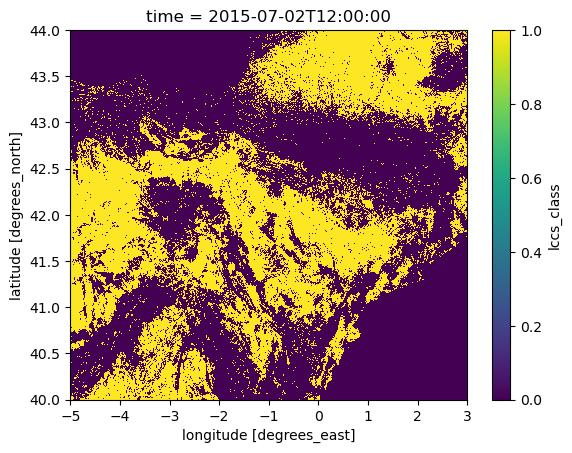

In [25]:
%%time
lc_binary.plot()

In [27]:
masked_lc = mask_dataset_by_geometry(lc_binary.to_dataset(), gdf.geometry[0])
masked_lc

<xarray.Dataset> Size: 10MB
Dimensions:     (lat: 1025, lon: 2363, time: 1)
Coordinates:
  * lat         (lat) float32 4kB 43.18 43.18 43.18 43.17 ... 40.34 40.34 40.34
  * lon         (lon) float32 9kB -4.404 -4.401 -4.399 ... 2.151 2.154 2.157
  * time        (time) datetime64[ns] 8B 2015-07-02T12:00:00
Data variables:
    lccs_class  (time, lat, lon) float32 10MB dask.array<chunksize=(1, 1025, 2363), meta=np.ndarray>
Attributes:
    geospatial_lon_units:       degrees_east
    geospatial_lon_min:         -4.405555248260498
    geospatial_lon_max:         2.1583333015441895
    geospatial_lon_resolution:  0.002777575
    geospatial_lat_units:       degrees_north
    geospatial_lat_min:         40.33611106337891
    geospatial_lat_max:         43.18333626328125
    geospatial_lat_resolution:  0.002780925
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.405555248260498 40.33611106337891...
    date_modified:              2025-08-26T16:04:45.077720

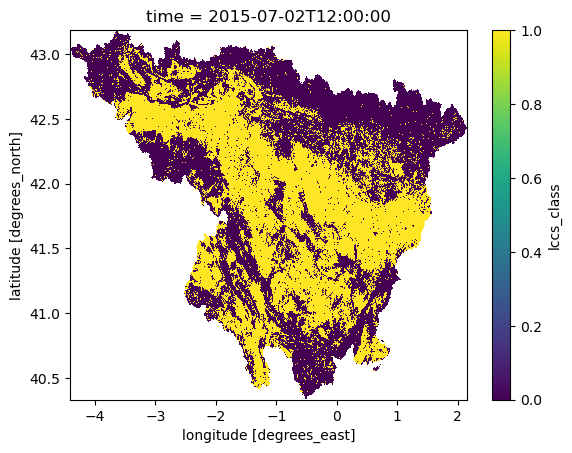

In [29]:
masked_lc.lccs_class.plot(vmin=0, vmax=1)

In [30]:
lc_gm

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.002777575, 0.0027771)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 2880, 1440)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (2880, 1440)
* tile_size: (2880, 1440)

In [39]:
target_gm = lc_gm.scale(xy_scale=0.31)
target_gm

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.008959919354838709, 0.008958387096774193)
* xy_bbox: (-5, 40, 3.0012079838709678, 43.99544064516129)
* ij_bbox: (0, 0, 893, 446)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (893, 446)
* tile_size: (893, 446)

In [77]:
lc_in_gm_sm_mode = resample_in_space(lc_binary.to_dataset().isel(time=0), target_gm = target_gm, agg_methods="mode")
# lc_in_gm_sm_mode=lc_in_gm_sm_mode.drop_vars('time')
lc_in_gm_sm_mode

<xarray.Dataset> Size: 409kB
Dimensions:      (lat: 446, lon: 893)
Coordinates:
    time         datetime64[ns] 8B 2015-07-02T12:00:00
    spatial_ref  int64 8B 0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.979 2.988 2.997
  * lat          (lat) float64 4kB 43.99 43.98 43.97 43.96 ... 40.02 40.01 40.0
Data variables:
    lccs_class   (lat, lon) uint8 398kB dask.array<chunksize=(446, 893), meta=np.ndarray>

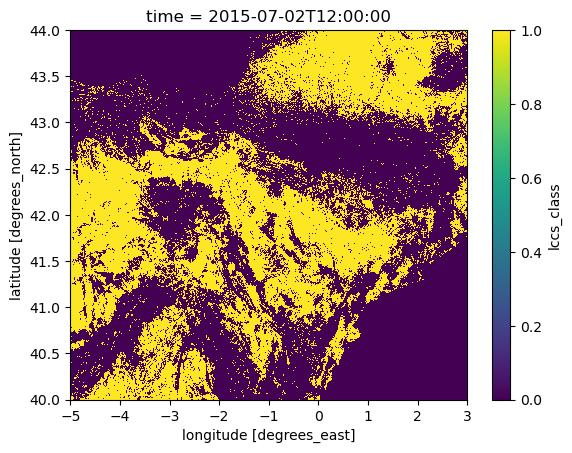

In [91]:
lc_binary.plot()

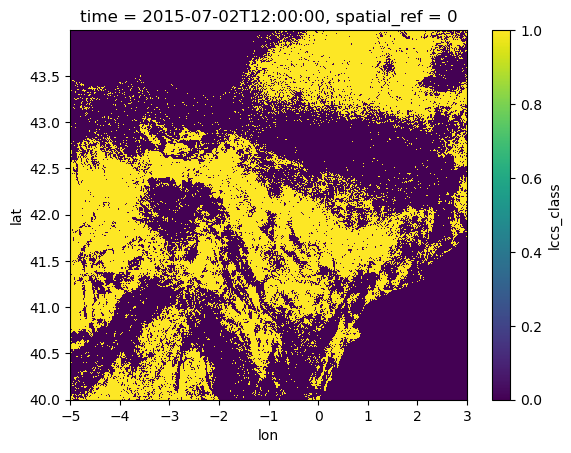

In [78]:
lc_in_gm_sm_mode.lccs_class.plot()

In [80]:
masked_lc2 = mask_dataset_by_geometry(lc_in_gm_sm_mode, gdf.geometry[0])
masked_lc2

<xarray.Dataset> Size: 941kB
Dimensions:      (lon: 733, lat: 318)
Coordinates:
    time         datetime64[ns] 8B 2015-07-02T12:00:00
    spatial_ref  int64 8B 0
  * lon          (lon) float64 6kB -4.404 -4.395 -4.386 ... 2.137 2.146 2.154
  * lat          (lat) float64 3kB 43.18 43.18 43.17 43.16 ... 40.36 40.35 40.34
Data variables:
    lccs_class   (lat, lon) float32 932kB dask.array<chunksize=(318, 733), meta=np.ndarray>
Attributes:
    geospatial_lon_units:       degrees_east
    geospatial_lon_min:         -4.408645325403225
    geospatial_lon_max:         2.1589755673387105
    geospatial_lon_resolution:  0.008959925
    geospatial_lat_units:       degrees_north
    geospatial_lat_min:         40.340418715725804
    geospatial_lat_max:         43.18918580040323
    geospatial_lat_resolution:  0.008958375
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.408645325403225 40.34041871572580...
    date_modified:              2025-08-26T16:26:08.600099

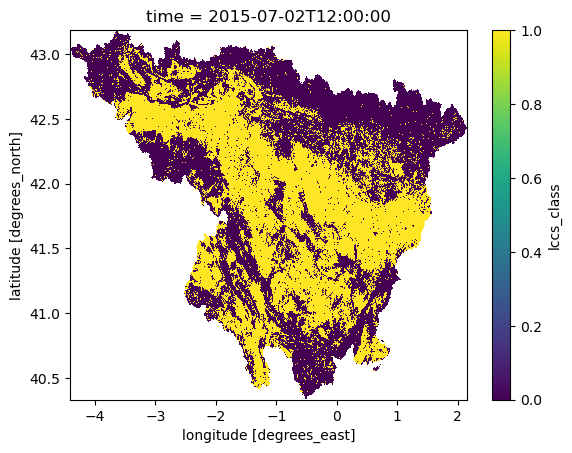

In [83]:
masked_lc.lccs_class.plot()

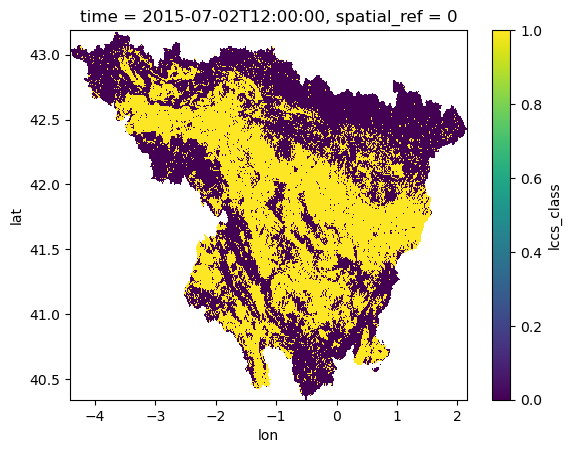

In [81]:
masked_lc2.lccs_class.plot()

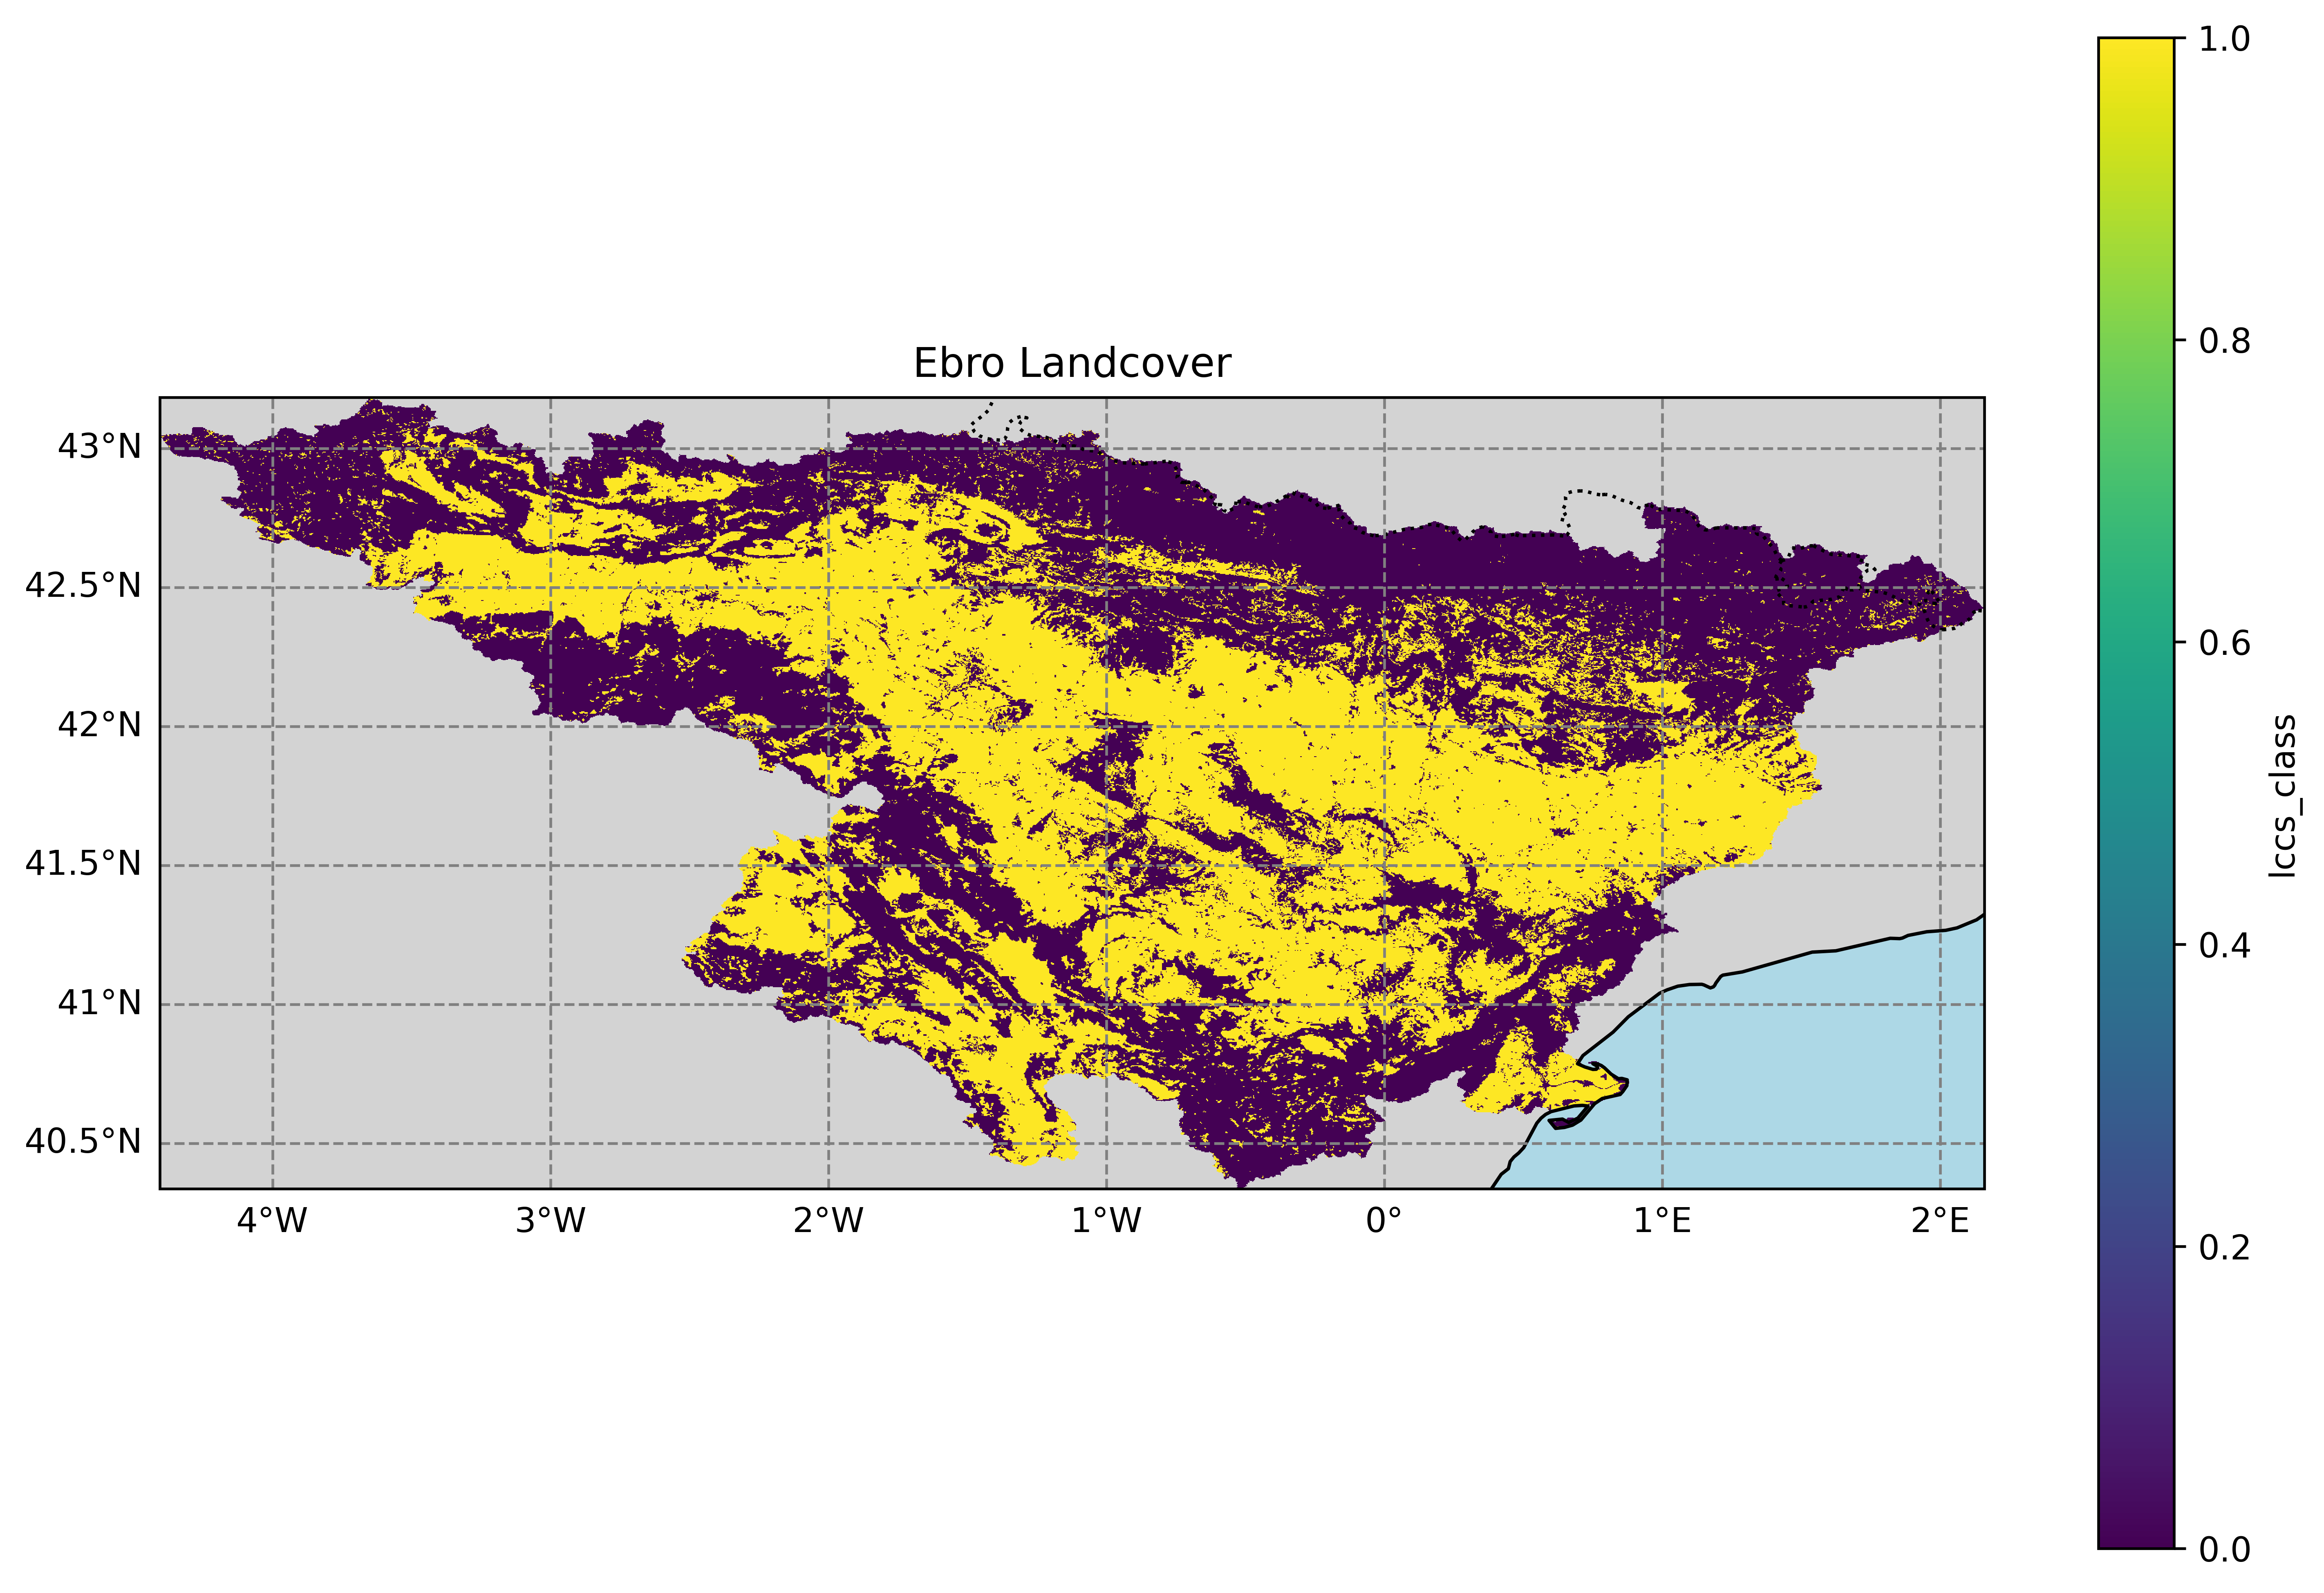

In [92]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

da = masked_lc["lccs_class"].isel(time=0)
plt.figure(figsize=(12, 8), dpi=600)

ax = plt.axes(projection=ccrs.PlateCarree())

da.plot.imshow(ax=ax, transform=ccrs.PlateCarree(), cmap="viridis", cbar_kwargs={'label': da.name})

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.set_title("Ebro Landcover")

gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

plt.show()


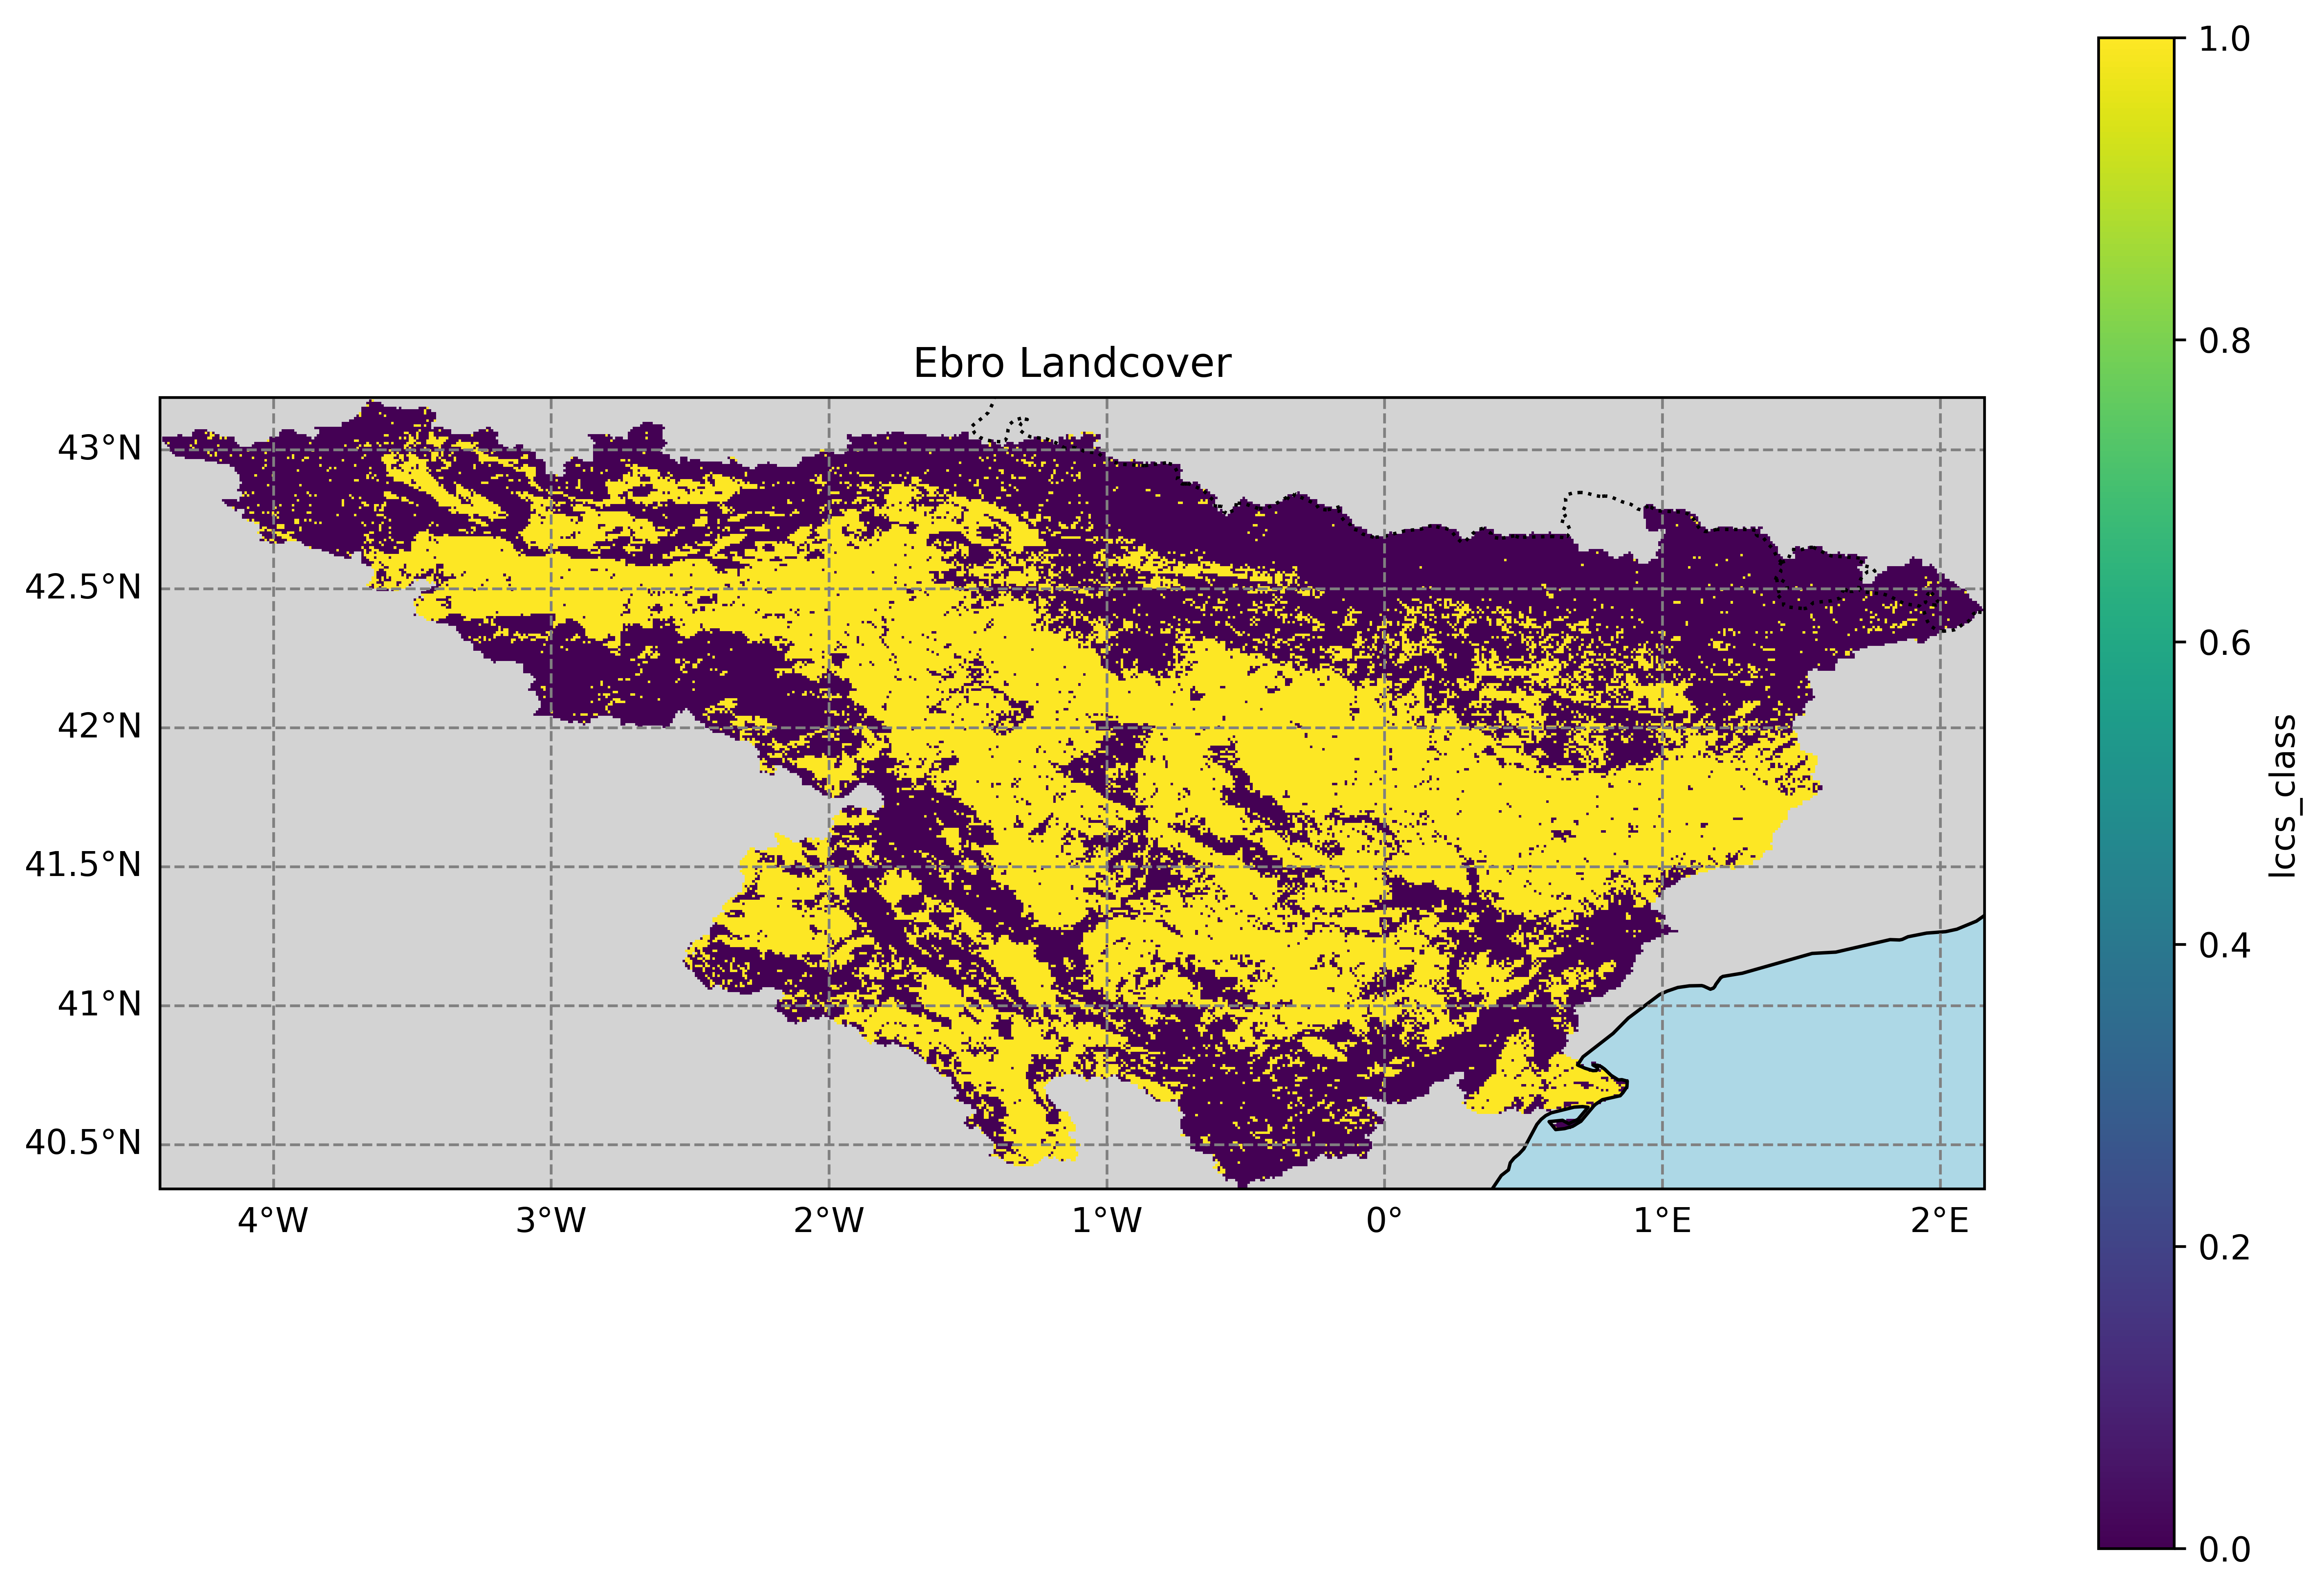

In [94]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

da = masked_lc2["lccs_class"]
plt.figure(figsize=(12, 8), dpi=600)

ax = plt.axes(projection=ccrs.PlateCarree())

da.plot.imshow(ax=ax, transform=ccrs.PlateCarree(), cmap="viridis", cbar_kwargs={'label': da.name})

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.set_title("Ebro Landcover")

gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

plt.show()


In [96]:
fsd.list_data_ids()

['irrigation_input_final.zarr',
 'irrigation_input.zarr',
 'calibratedv1.zarr',
 'soil_moisture_filled.zarr']

In [97]:
irr_input = fsd.open_data("irrigation_input_final.zarr")

In [98]:
irr_input

<xarray.Dataset> Size: 548MB
Dimensions:        (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat            (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    number         int64 8B ...
    spatial_ref    int64 8B ...
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    crs            (time) |S1 31B dask.array<chunksize=(1,), meta=np.ndarray>
    lc_binary      (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>
    pev            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm            (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    stl1           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

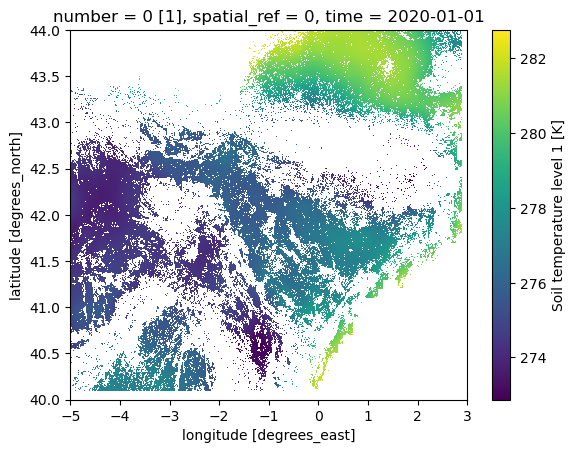

In [99]:
irr_input.stl1.isel(time=0).plot()

In [100]:
masked_irr_input = mask_dataset_by_geometry(irr_input, gdf.geometry[0])
masked_irr_input

<xarray.Dataset> Size: 381MB
Dimensions:        (lat: 320, lon: 736, time: 31)
Coordinates:
  * lat            (lat) float64 3kB 43.19 43.18 43.17 ... 40.36 40.35 40.34
  * lon            (lon) float64 6kB -4.406 -4.397 -4.388 ... 2.138 2.147 2.156
    number         int64 8B ...
    spatial_ref    int64 8B ...
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    SWI            (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    crs            (time, lat, lon) object 58MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    lc_binary      (lat, lon) float32 942kB dask.array<chunksize=(320, 736), meta=np.ndarray>
    pev            (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    sf             (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    ssm            (time, lat, lon) float64 58MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 58MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    stl1           (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    tp             (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
Attributes: (12/33)
    Conventions:                CF-1.6
    archive_facility:           VITO
    copyright:                  Copernicus Service information 2020
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_min:         40.339285712498786
    geospatial_lon_max:         2.160714287499627
    ...                         ...
    geospatial_lon_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lat_resolution:  0.008928575
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    date_modified:              2025-08-26T16:57:23.226724

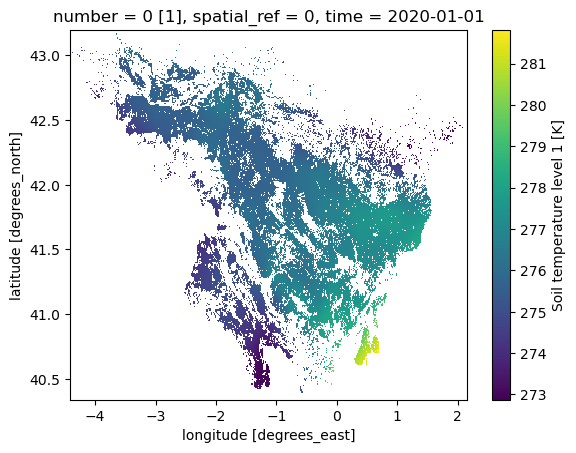

In [101]:
masked_irr_input.stl1.isel(time=0).plot()

In [102]:
fsd.write_data(masked_irr_input, "irrigation_input_masked_ebro_basin.zarr")

/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.12/site-packages/xcube/core/store/fs/impl/dataset.py:207: SerializationWarning: variable None has data in the form of a dask array with dtype=object, which means it is being loaded into memory to determine a data type that can be safely stored on disk. To avoid this, coerce this variable to a fixed-size dtype with astype() before saving it.
  data.to_zarr(


'irrigation_input_masked_ebro_basin.zarr'